## Tugas 1: Klasifikasi Tanpa Differential Privacy 

### Persiapan Data

In [1]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Baca dataset langsung dari GitHub
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/refs/heads/master/heart.csv'
df = pd.read_csv(url)

# Tampilkan data
print(df)

# Pisahkan fitur dan label
X = df.drop('target', axis=1)
y = df['target']

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalisasi data menggunakan MinMaxScaler agar rentangnya berada di [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

### Klasifikasi

In [2]:
# Import dan latih model Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

[0 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 1
 1 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 0 1
 0 1 1 1 0 0 1 0 1 0 1 0 0 1 1 0 1]


### Evaluasi

In [3]:
# Evaluasi hasil prediksi
from sklearn.metrics import accuracy_score, classification_report

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Akurasi: 0.8021978021978022
              precision    recall  f1-score   support

           0       0.77      0.80      0.79        41
           1       0.83      0.80      0.82        50

    accuracy                           0.80        91
   macro avg       0.80      0.80      0.80        91
weighted avg       0.80      0.80      0.80        91



## Tugas 2: Penambahan Noise Laplace 

### Instalasi diffprivlib

In [4]:
!pip install diffprivlib

### Persiapan Data

In [5]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Baca dataset langsung dari GitHub
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/refs/heads/master/heart.csv'
df = pd.read_csv(url)

# Tampilkan data
print(df)

# Pisahkan fitur dan label
X = df.drop('target', axis=1)
y = df['target']

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalisasi data menggunakan MinMaxScaler agar rentangnya berada di [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

### Penambahan Noise dengan Laplace Mechanism

In [6]:
# Import Laplace Mechanism dari diffprivlib
from diffprivlib.mechanisms import Laplace

# Salin data dan siapkan mekanisme Laplace
X_noisy = X_train.copy()
lap = Laplace(epsilon=1.0, sensitivity=1.0)

import numpy as np
X_noisy_df = pd.DataFrame(X_noisy)

# Tambahkan noise Laplace ke setiap fitur
for col in X_noisy_df.columns:
    X_noisy_df[col] = X_noisy_df[col].apply(lambda x: x + lap.randomise(x))

### Data Sebelum dan Sesudah Diberi Noise

In [7]:
# Tampilkan 5 baris pertama data asli
print("Sebelum (5 baris):")
X_train_df = pd.DataFrame(X_train)
X_train_df.columns = df.drop('target', axis=1).columns
X_train_df.head()

Sebelum (5 baris):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.208333,0.0,0.666667,0.000000,0.157044,0.0,0.5,0.798246,0.0,0.000000,1.0,0.0,0.666667
1,0.000000,1.0,0.333333,0.367347,0.168591,0.0,0.0,1.000000,0.0,0.000000,1.0,0.0,0.666667
2,0.437500,0.0,0.666667,0.265306,0.203233,0.0,0.5,0.614035,0.0,0.285714,0.5,0.0,0.666667
3,0.520833,1.0,0.000000,0.469388,0.249423,0.0,0.5,0.631579,0.0,0.214286,1.0,0.0,0.666667
4,0.187500,1.0,0.666667,0.448980,0.101617,0.0,0.5,0.745614,0.0,0.000000,1.0,1.0,0.666667


In [8]:
# Tampilkan 5 baris pertama data yang sudah diberi noise
print("\nSesudah (5 baris):")
X_noisy_df.columns = df.drop('target', axis=1).columns
X_noisy_df.head()


Sesudah (5 baris):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.847568,-0.034693,0.166481,-2.380666,0.407317,0.991683,2.536494,0.606481,-0.180298,-0.151927,1.829651,-0.011382,3.538318
1,-1.683838,3.512732,0.959969,0.677684,0.154825,0.426785,2.366979,2.896863,-1.568074,0.981610,1.352169,-3.816646,1.409711
2,-1.395187,-0.458735,3.553852,-1.750982,1.122661,3.544631,2.342409,1.726781,0.928992,1.542744,-0.436609,0.132906,0.521024
3,0.971964,3.117257,-0.070739,0.914889,-0.738229,0.562449,0.872416,1.493255,0.478204,-0.259127,2.094622,0.375777,4.462703
4,0.144560,3.781034,2.354394,1.696983,-0.051222,0.051177,0.332139,1.201911,0.384082,-2.305724,3.621102,3.293707,1.144221


### Klasifikasi dan Evaluasi

In [9]:
# Latih model dengan data yang sudah diberi noise
model_noise = LogisticRegression(max_iter=1000)
model_noise.fit(X_noisy_df, y_train)
y_pred_noise = model_noise.predict(X_test)

# Evaluasi hasil prediksi
print("Akurasi dengan noise:", accuracy_score(y_test, y_pred_noise))
print(classification_report(y_test, y_pred_noise))

Akurasi dengan noise: 0.5494505494505495
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.55      1.00      0.71        50

    accuracy                           0.55        91
   macro avg       0.27      0.50      0.35        91
weighted avg       0.30      0.55      0.39        91



c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 i

## Tugas 3: Penambahan Noise Gaussian

### Persiapan Data

In [30]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Baca dataset langsung dari GitHub
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/refs/heads/master/heart.csv'
df = pd.read_csv(url)

# Tampilkan data
print(df)

# Pisahkan fitur dan label
X = df.drop('target', axis=1)
y = df['target']

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalisasi data menggunakan MinMaxScaler agar rentangnya berada di [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

### Penambahan Gaussian Noise

In [31]:
noise = np.random.normal(loc=0, scale=0.3, size=X_train.shape)
X_noisy = X_train + noise

X_noisy_df = pd.DataFrame(X_noisy)

### Data Sebelum dan Sesudah Diberi Noise

In [32]:
print("Sebelum (5 baris):")
X_train_df = pd.DataFrame(X_train)
X_train_df.columns = df.drop('target', axis=1).columns
X_train_df.head()

Sebelum (5 baris):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.208333,0.0,0.666667,0.000000,0.157044,0.0,0.5,0.798246,0.0,0.000000,1.0,0.0,0.666667
1,0.000000,1.0,0.333333,0.367347,0.168591,0.0,0.0,1.000000,0.0,0.000000,1.0,0.0,0.666667
2,0.437500,0.0,0.666667,0.265306,0.203233,0.0,0.5,0.614035,0.0,0.285714,0.5,0.0,0.666667
3,0.520833,1.0,0.000000,0.469388,0.249423,0.0,0.5,0.631579,0.0,0.214286,1.0,0.0,0.666667
4,0.187500,1.0,0.666667,0.448980,0.101617,0.0,0.5,0.745614,0.0,0.000000,1.0,1.0,0.666667


In [33]:
print("Setelah (5 baris):")
X_noisy_df = pd.DataFrame(X_noisy)
X_noisy_df.columns = df.drop('target', axis=1).columns
X_noisy_df.head()

Setelah (5 baris):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.636209,0.088396,1.088640,0.321479,-0.091958,-0.088629,0.562825,1.599266,-0.330380,-0.169892,1.281443,-0.346358,0.879375
1,0.230282,1.373956,0.449171,0.465990,-0.026866,-0.609826,-0.118029,1.244214,0.252409,-0.256704,0.464473,0.041094,0.630175
2,0.531377,0.120416,0.214992,0.583532,0.003868,-0.321381,0.529192,0.848516,0.074008,0.703629,0.420273,-0.561422,0.503327
3,0.336836,1.242117,0.033947,0.567699,0.204286,0.012020,0.357075,0.344122,-0.442992,0.565206,1.086232,-0.226810,0.661799
4,0.315042,0.083483,0.267446,1.001950,-0.284759,-0.029086,1.382009,0.452890,0.156811,0.277581,0.858308,0.580649,0.574124


### Klasifikasi dan Evaluasi

In [34]:
# Latih model dengan data yang sudah diberi noise
model_noise = LogisticRegression(max_iter=1000)
model_noise.fit(X_noisy_df, y_train)
y_pred_noise = model_noise.predict(X_test)

# Evaluasi hasil prediksi
print("Akurasi dengan noise:", accuracy_score(y_test, y_pred_noise))
print(classification_report(y_test, y_pred_noise))

Akurasi dengan noise: 0.8131868131868132
              precision    recall  f1-score   support

           0       0.79      0.80      0.80        41
           1       0.84      0.82      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Tugas 4: Gunakan DP Logistic Regression dari diffprivlib

### Persiapan Data

In [10]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Baca dataset langsung dari GitHub
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/refs/heads/master/heart.csv'
df = pd.read_csv(url)

# Tampilkan data
print(df)

# Pisahkan fitur dan label
X = df.drop('target', axis=1)
y = df['target']

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalisasi data menggunakan MinMaxScaler agar rentangnya berada di [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

### Persiapan Library

In [11]:
# Import Logistic Regression versi DP dari diffprivlib
from diffprivlib.models import LogisticRegression as DPLogisticRegression

### Klasifikasi dan Evaluasi

In [12]:
# Hitung data_norm maksimum
norms = np.linalg.norm(X_train, axis=1)
max_norm = np.max(norms)

# Inisialisasi model dengan nilai data_norm
dp_model = DPLogisticRegression(epsilon=1.0, data_norm=max_norm)

# Latih model Logistic Regression dengan Differential Privacy
dp_model.fit(X_train, y_train)
y_pred_dp = dp_model.predict(X_test)

# Evaluasi hasil prediksi model DP
print("Akurasi dengan DP Logistic Regression:", accuracy_score(y_test, y_pred_dp))
print(classification_report(y_test, y_pred_dp))

Akurasi dengan DP Logistic Regression: 0.5494505494505495
              precision    recall  f1-score   support

           0       0.50      0.37      0.42        41
           1       0.57      0.70      0.63        50

    accuracy                           0.55        91
   macro avg       0.54      0.53      0.53        91
weighted avg       0.54      0.55      0.54        91



## Tugas 5: Eksperimen dengan Nilai Epsilon

### Gunakan nilai epsilon dari 0.01 sampai 100 (misalnya dalam log scale) 

In [28]:
# Evaluasi akurasi model terhadap berbagai nilai epsilon
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

epsilons = np.logspace(-2, 2, 50)
accuracy = []

for eps in epsilons:
    dp_model = DPLogisticRegression(epsilon=eps, data_norm=max_norm)
    dp_model.fit(X_train, y_train)
    acc = dp_model.score(X_test, y_test)
    accuracy.append(acc)

### Buat grafik hubungan antara epsilon dan akurasi model 

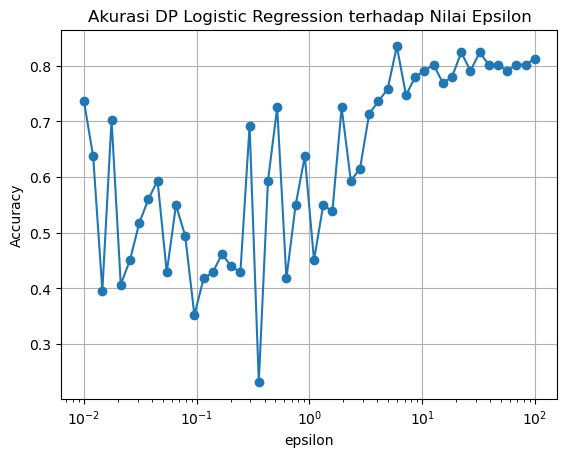

In [29]:
# Visualisasi hasil
plt.semilogx(epsilons, accuracy, marker='o')
plt.title("Akurasi DP Logistic Regression terhadap Nilai Epsilon")
plt.xlabel("epsilon")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

### Jelaskan trade-off antara privasi dan performa model 

Differential Privacy mengontrol seberapa besar perlindungan data individu dengan noise, namun hal tersebut berpengaruh besar terhadap performa model. Semakin besar noise yang diberikan, semakin tinggi privasi dan perlindungan data. Meski begitu, noise yang tinggi membuat model sulit mempelajari pola data, sehingga akurasi menjadi rendah dan tidak stabil. Jika noise dikurangi, model dapat belajar dengan lebih baik sehingga meningkatkan akurasi model. Akan tetapi, noise yang berkurang berarti perlindungan privasi data menjadi lebih lemah. Dengan demikian, diperlukan pengaturan nilai epsilon dan jumlah noise yang tepat untuk mencapai titik keseimbangan antara privasi data dengan akurasi model.